# Alon Cohen - DBSCAN and K-Means Comparison

## Objective

This notebook covers Alon's assigned clustering part for the mini-project: apply DBSCAN to a small, reproducible subset of the preprocessed NYC PLUTO data, tune its hyperparameters, evaluate noise and silhouette behavior, and compare DBSCAN with the K-Means result handled in Elie's validated notebook.

**Source of truth:** `notebooks/02_preprocessing/preprocessing.ipynb` creates the final standardized matrix and K-Means outputs. This notebook only reads those outputs and does not redo preprocessing.


## 1. Imports and Path Setup

All paths use `pathlib` and are resolved from the project root, so the notebook can run from the repository root or from `notebooks/04_clustering/`.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
SAMPLE_SIZE = 10_000
SILHOUETTE_SAMPLE_SIZE = 10_000

search_dir = Path.cwd().resolve()
for candidate in [search_dir, *search_dir.parents]:
    if (candidate / "notebooks" / "02_preprocessing" / "preprocessing.ipynb").exists() and (candidate / "data" / "processed").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root. Expected notebooks/02_preprocessing/preprocessing.ipynb and data/processed/.")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

X_SCALED_PATH = PROCESSED_DIR / "X_scaled.csv"
FEATURES_PATH = PROCESSED_DIR / "X_scaled_features.csv"
SHARED_SAMPLE_INDEX_PATH = PROCESSED_DIR / "sample_index.csv"
KMEANS_LABELS_PATH = PROCESSED_DIR / "cluster_labels.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DIR}")
print(f"Working subset size: {SAMPLE_SIZE:,}")


Project root: /Users/ouriouahba/Desktop/NYC_PLUTO
Processed data directory: /Users/ouriouahba/Desktop/NYC_PLUTO/data/processed
Working subset size: 10,000


## 2. Load Preprocessed `X_scaled` from Elie's Validated Output

Alon's DBSCAN analysis uses the exact standardized feature matrix saved by Elie's preprocessing notebook: `data/processed/X_scaled.csv`.


In [2]:
if not X_SCALED_PATH.exists():
    raise FileNotFoundError(
        f"Missing {X_SCALED_PATH}. Run notebooks/02_preprocessing/preprocessing.ipynb before this notebook."
    )

X_scaled = pd.read_csv(X_SCALED_PATH)

if FEATURES_PATH.exists():
    feature_names = pd.read_csv(FEATURES_PATH)["feature"].tolist()
    if len(feature_names) == X_scaled.shape[1]:
        X_scaled.columns = feature_names

print(f"Loaded X_scaled: {X_scaled.shape[0]:,} rows x {X_scaled.shape[1]} features")
print("Features:", list(X_scaled.columns))
X_scaled.head()


Loaded X_scaled: 682,515 rows x 16 features
Features: ['lotarea', 'bldgarea', 'numfloors', 'lotfront', 'lotdepth', 'unitstotal', 'unitsres', 'resarea', 'comarea', 'officearea', 'retailarea', 'garagearea', 'strgearea', 'building_age', 'building_density', 'residential_ratio']


,lotarea,bldgarea,numfloors,lotfront,lotdepth,unitstotal,unitsres,resarea,comarea,officearea,retailarea,garagearea,strgearea,building_age,building_density,residential_ratio
0,-0.059590,-1.204015,-0.223780,-0.630419,-0.618660,-1.125912,-0.552841,0.035082,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,-0.197778,-1.027977,0.329387
1,1.992838,1.665610,-0.223780,1.746536,-0.540113,1.452612,3.249408,0.669584,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,-0.410806,-0.246031,0.329387
2,1.992838,1.665610,0.086105,0.458914,-0.650079,1.452612,3.249408,0.669584,2.001848,4.413006,-0.318567,-0.120596,-0.101129,-0.349941,-0.246031,0.329387
3,1.007900,0.132539,-0.533666,-0.519980,-0.728625,0.163350,-1.456106,-3.522005,2.169173,-0.194941,3.154600,-0.120596,-0.101129,-0.623833,-0.769182,-3.468246
4,1.992838,1.665610,-0.223780,0.484014,1.698467,-1.125912,-1.456106,-3.522005,2.894946,-0.194941,-0.318567,-0.120596,-0.101129,0.623900,-0.246031,-3.468246


## 3. Create or Load the Working Subset with `SAMPLE_SIZE = 10000`

The professor asks us to apply the clustering algorithms to a small part of the dataset. DBSCAN and `silhouette_score` are expensive, so this notebook uses a 10,000-row subset.

Sampling rule:

- If `data/processed/sample_index.csv` exists, draw the 10,000 DBSCAN rows from that shared project sample.
- If it does not exist, create a deterministic 10,000-row sample from `X_scaled` with `random_state=42` and save it as `sample_index.csv`.

K-Means and DBSCAN are both evaluated on the exact same subset.


In [3]:
rng = np.random.RandomState(RANDOM_STATE)

if SHARED_SAMPLE_INDEX_PATH.exists():
    shared_sample_idx = pd.read_csv(SHARED_SAMPLE_INDEX_PATH).iloc[:, 0].astype(int).to_numpy()
    if shared_sample_idx.min() < 0 or shared_sample_idx.max() >= len(X_scaled):
        raise ValueError("sample_index.csv contains row positions outside X_scaled.")
    subset_size = min(SAMPLE_SIZE, len(shared_sample_idx))
    selected_positions = rng.choice(len(shared_sample_idx), size=subset_size, replace=False)
    sample_idx = shared_sample_idx[selected_positions]
    sample_source = f"{subset_size:,} rows drawn from existing shared sample_index.csv"
else:
    subset_size = min(SAMPLE_SIZE, len(X_scaled))
    sample_idx = rng.choice(X_scaled.index.to_numpy(), size=subset_size, replace=False)
    pd.DataFrame({"row_index": sample_idx}).to_csv(SHARED_SAMPLE_INDEX_PATH, index=False)
    selected_positions = np.arange(subset_size)
    sample_source = f"created {subset_size:,}-row sample_index.csv from X_scaled"

X_sample = X_scaled.iloc[sample_idx].copy()
X_sample_array = X_sample.to_numpy(dtype=np.float32)

print(sample_source)
print(f"X_sample shape: {X_sample.shape}")
X_sample.head()


10,000 rows drawn from existing shared sample_index.csv
X_sample shape: (10000, 16)


,lotarea,bldgarea,numfloors,lotfront,lotdepth,unitstotal,unitsres,resarea,comarea,officearea,retailarea,garagearea,strgearea,building_age,building_density,residential_ratio
307260,0.953701,0.001085,0.086105,-0.570180,1.698467,0.163350,-0.024466,0.354120,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,-2.328054,-0.827909,0.329387
682384,0.397686,-1.247706,-0.223780,-0.670579,1.698467,0.163350,-0.024466,0.023515,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,0.715197,-1.287588,0.329387
298347,-1.204888,-1.378412,-0.223780,0.007117,-0.540113,-1.125912,-0.552841,-0.011088,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,-1.475944,-0.414175,0.329387
201850,-1.204888,0.378191,0.086105,-0.670579,1.698467,1.078096,-0.024466,0.251211,1.847925,-0.194941,2.724609,-0.120596,-0.101129,0.380440,1.445542,-0.936491
333938,1.052740,-0.717179,-0.223780,-0.560140,-0.430148,-1.125912,-0.552841,0.163967,-0.425647,-0.194941,-0.318567,-0.120596,-0.101129,0.106547,-1.315069,0.329387


## 4. DBSCAN Theoretical Overview

DBSCAN defines clusters as connected dense regions and labels isolated observations as noise (`-1`). Unlike K-Means, it does not require choosing the number of clusters in advance and can discover non-spherical cluster shapes.

DBSCAN uses Euclidean distance by default. Because distance calculations are sensitive to scale, this notebook uses Elie's standardized `X_scaled` matrix.


## 5. DBSCAN Hyperparameters: `eps` and `min_samples`

- `eps`: neighborhood radius around each point. A larger `eps` connects more points, usually reducing noise and merging clusters.
- `min_samples`: minimum number of points required inside the `eps` radius for a point to be a core point. A larger value makes DBSCAN stricter and usually increases noise.

A configuration is useful only if it creates at least two non-noise clusters and does not classify almost all observations as noise.


## 6. Professor Toy DBSCAN Example

The toy example shows two compact groups and one isolated point. We first run DBSCAN with `eps=0.5` and `min_samples=3`, then test how labels change for several `eps` values.


In [4]:
X_toy = np.array([
    [1.0, 1.0],
    [1.2, 1.1],
    [1.1, 1.3],
    [6.0, 5.0],
    [6.2, 5.1],
    [5.8, 4.9],
    [8.0, 1.0],
])

toy_model = DBSCAN(eps=0.5, min_samples=3)
toy_labels = toy_model.fit_predict(X_toy)
noise_points = np.where(toy_labels == -1)[0]

print("eps=0.5, min_samples=3")
print("Labels:", toy_labels.tolist())
print("Noise point indices:", noise_points.tolist())
print("Noise point coordinates:", X_toy[noise_points].tolist())

print("Effect of changing eps with min_samples=3:")
toy_rows = []
for eps_test in [0.3, 0.5, 1.0, 3.0]:
    labels = DBSCAN(eps=eps_test, min_samples=3).fit_predict(X_toy)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = int((labels == -1).sum())
    toy_rows.append({"eps": eps_test, "labels": labels.tolist(), "n_clusters": n_clusters, "n_noise": n_noise})

toy_results = pd.DataFrame(toy_rows)
toy_results


eps=0.5, min_samples=3
Labels: [0, 0, 0, 1, 1, 1, -1]
Noise point indices: [6]
Noise point coordinates: [[8.0, 1.0]]
Effect of changing eps with min_samples=3:


,eps,labels,n_clusters,n_noise
0,0.3,"[0, 0, 0, 1, 1, 1, -1]",2,1
1,0.5,"[0, 0, 0, 1, 1, 1, -1]",2,1
2,1.0,"[0, 0, 0, 1, 1, 1, -1]",2,1
3,3.0,"[0, 0, 0, 1, 1, 1, -1]",2,1


**Toy example answer:** With `eps=0.5` and `min_samples=3`, point index `6`, coordinates `[8.0, 1.0]`, is labeled as noise. For the tested values `eps=0.3`, `0.5`, `1.0`, and `3.0`, the labels do not change. Therefore, these tested values do not merge the clusters and do not absorb the noise point.


## 7. Baseline DBSCAN on the NYC PLUTO Subset

The baseline run gives a first reference before tuning. Silhouette is computed only on non-noise points and only when at least two non-noise clusters exist.


In [5]:
def summarize_dbscan(labels, X, silhouette_sample_size=SILHOUETTE_SAMPLE_SIZE):
    labels = np.asarray(labels)
    non_noise_mask = labels != -1
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_count = int((labels == -1).sum())
    noise_pct = noise_count / len(labels) * 100

    if n_clusters >= 2 and non_noise_mask.sum() > 100:
        silhouette = silhouette_score(
            X[non_noise_mask],
            labels[non_noise_mask],
            sample_size=min(silhouette_sample_size, int(non_noise_mask.sum())),
            random_state=RANDOM_STATE,
        )
    else:
        silhouette = np.nan

    return {
        "n_clusters": n_clusters,
        "noise_count": noise_count,
        "noise_pct": noise_pct,
        "silhouette": silhouette,
    }

baseline_eps = 0.5
baseline_min_samples = 5
baseline_labels = DBSCAN(eps=baseline_eps, min_samples=baseline_min_samples, n_jobs=-1).fit_predict(X_sample_array)
baseline_summary = summarize_dbscan(baseline_labels, X_sample_array)

baseline_df = pd.DataFrame([{ "eps": baseline_eps, "min_samples": baseline_min_samples, **baseline_summary }])
baseline_df


,eps,min_samples,n_clusters,noise_count,noise_pct,silhouette
0,0.5,5,74,3432,34.32,-0.004378


## 8. DBSCAN Parameter Tuning

The tuning grid tests a small range of `eps` and `min_samples` values. For each configuration, the table records the number of clusters, noise count, noise percentage, and silhouette score when valid. Invalid silhouette cases are stored as `NaN`.


In [6]:
eps_values = [0.5, 0.8, 1.0, 1.2, 1.5]
min_samples_values = [5, 10, 20, 40]

rows = []
for eps in eps_values:
    for min_samples in min_samples_values:
        labels = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1).fit_predict(X_sample_array)
        summary = summarize_dbscan(labels, X_sample_array, silhouette_sample_size=5_000)
        rows.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": summary["n_clusters"],
            "noise_count": summary["noise_count"],
            "noise_pct": round(summary["noise_pct"], 2),
            "silhouette": summary["silhouette"],
        })

dbscan_results_df = pd.DataFrame(rows)
dbscan_results_df


,eps,min_samples,n_clusters,noise_count,noise_pct,silhouette
0,0.5,5,74,3432,34.32,0.004767
1,0.5,10,40,4355,43.55,0.074810
2,0.5,20,13,5546,55.46,0.079598
3,0.5,40,9,6582,65.82,0.327803
4,0.8,5,48,1813,18.13,0.056822
5,0.8,10,32,2268,22.68,0.136218
6,0.8,20,21,3079,30.79,0.195155
7,0.8,40,9,4247,42.47,0.275384
8,1.0,5,31,1296,12.96,0.141038
9,1.0,10,19,1604,16.04,0.187204


### Tuning Visualizations

The plots summarize how changing `eps` and `min_samples` changes the DBSCAN result.


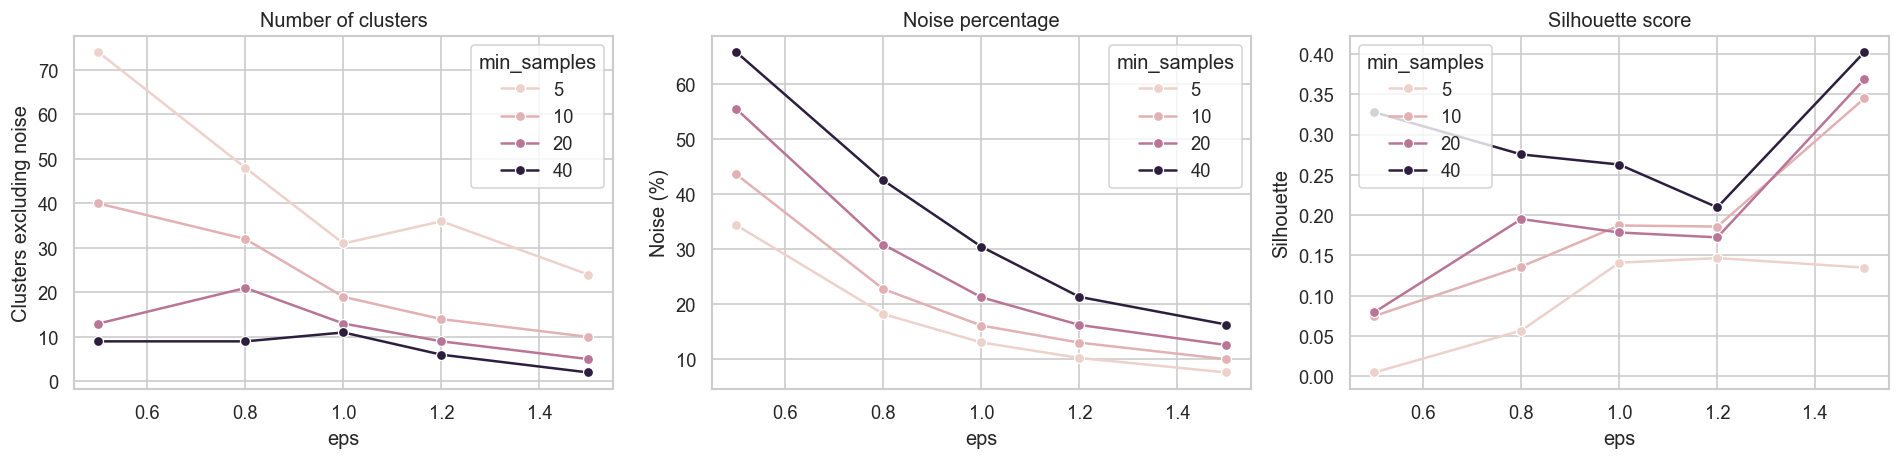

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.lineplot(data=dbscan_results_df, x="eps", y="n_clusters", hue="min_samples", marker="o", ax=axes[0])
axes[0].set_title("Number of clusters")
axes[0].set_ylabel("Clusters excluding noise")

sns.lineplot(data=dbscan_results_df, x="eps", y="noise_pct", hue="min_samples", marker="o", ax=axes[1])
axes[1].set_title("Noise percentage")
axes[1].set_ylabel("Noise (%)")

sns.lineplot(data=dbscan_results_df, x="eps", y="silhouette", hue="min_samples", marker="o", ax=axes[2])
axes[2].set_title("Silhouette score")
axes[2].set_ylabel("Silhouette")

for ax in axes:
    ax.set_xlabel("eps")
    ax.legend(title="min_samples")

plt.tight_layout()
plt.show()


## 9. Select Final DBSCAN Configuration

The final configuration is selected from the tuning grid using these criteria:

- at least two non-noise clusters,
- valid silhouette score,
- noise percentage between 5% and 60%,
- preference for higher silhouette, then lower noise, then fewer clusters for readability.

This avoids choosing a configuration only because it has many tiny clusters or because it excludes too much of the sample as noise.


In [8]:
valid_configs = dbscan_results_df[
    (dbscan_results_df["n_clusters"] >= 2)
    & (dbscan_results_df["noise_pct"].between(5, 60))
    & (dbscan_results_df["silhouette"].notna())
].copy()

if valid_configs.empty:
    raise RuntimeError("No DBSCAN configuration produced at least two clusters with a usable noise percentage and silhouette score.")

selected_row = valid_configs.sort_values(
    ["silhouette", "noise_pct", "n_clusters"],
    ascending=[False, True, True],
).iloc[0]

selected_eps = float(selected_row["eps"])
selected_min_samples = int(selected_row["min_samples"])

print("Selected DBSCAN configuration")
print(f"eps = {selected_eps}")
print(f"min_samples = {selected_min_samples}")
print(f"clusters = {int(selected_row['n_clusters'])}")
print(f"noise = {selected_row['noise_pct']:.2f}%")
print(f"silhouette = {selected_row['silhouette']:.4f}")


Selected DBSCAN configuration
eps = 1.5
min_samples = 40
clusters = 2
noise = 16.22%
silhouette = 0.4022


The selected DBSCAN configuration is the best compromise in the tested grid under the constraints above. It gives a valid silhouette score, keeps the noise percentage in a usable range, and produces a result that can be compared with K-Means on the same subset.


## 10. Cluster Size and Noise Analysis

The selected DBSCAN model is fitted on the same 10,000-row subset. Label `-1` represents noise.


In [9]:
final_dbscan = DBSCAN(eps=selected_eps, min_samples=selected_min_samples, n_jobs=-1)
dbscan_labels = final_dbscan.fit_predict(X_sample_array)
dbscan_summary = summarize_dbscan(dbscan_labels, X_sample_array)

dbscan_cluster_summary = (
    pd.Series(dbscan_labels, name="cluster")
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="count")
)
dbscan_cluster_summary["percentage"] = (dbscan_cluster_summary["count"] / len(dbscan_labels) * 100).round(2)

print("Final DBSCAN results")
print(f"Clusters: {dbscan_summary['n_clusters']}")
print(f"Noise points: {dbscan_summary['noise_count']:,}")
print(f"Noise percentage: {dbscan_summary['noise_pct']:.2f}%")
print(f"Silhouette: {dbscan_summary['silhouette']:.4f}" if not np.isnan(dbscan_summary["silhouette"]) else "Silhouette: not valid")

dbscan_cluster_summary


Final DBSCAN results
Clusters: 2
Noise points: 1,622
Noise percentage: 16.22%
Silhouette: 0.4053


,cluster,count,percentage
0,-1,1622,16.22
1,0,8138,81.38
2,1,240,2.40


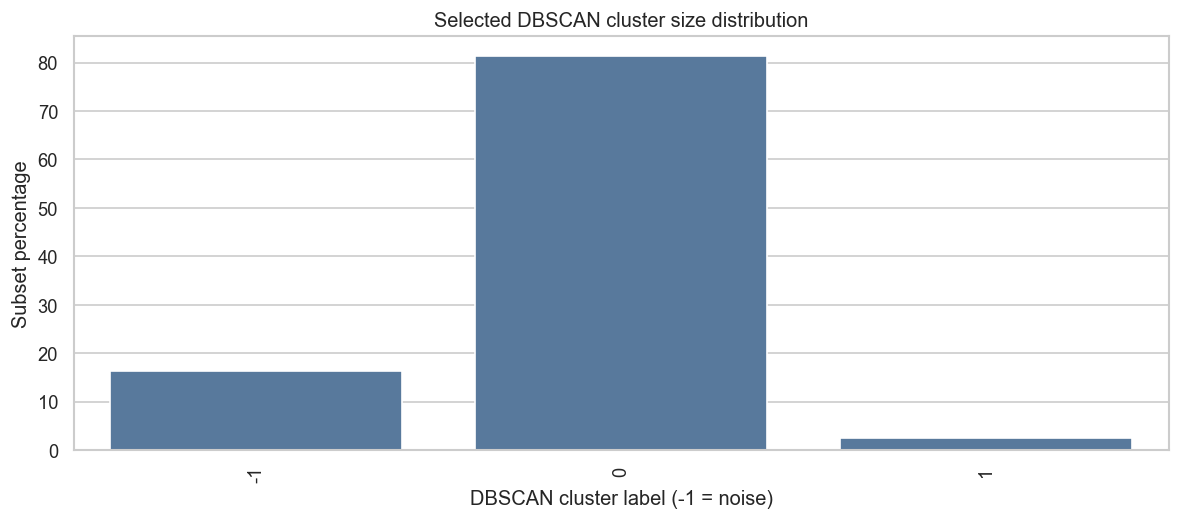

In [10]:
plot_df = dbscan_cluster_summary.copy()
plot_df["cluster"] = plot_df["cluster"].astype(str)

plt.figure(figsize=(10, 4.5))
sns.barplot(data=plot_df, x="cluster", y="percentage", color="#4C78A8")
plt.title("Selected DBSCAN cluster size distribution")
plt.xlabel("DBSCAN cluster label (-1 = noise)")
plt.ylabel("Subset percentage")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 11. K-Means vs DBSCAN Comparison on the Exact Same Subset

The comparison uses the exact same `X_sample` for both algorithms.

If Elie's saved K-Means labels in `cluster_labels.csv` match the shared sample, this notebook loads the corresponding labels for the selected 10,000 rows. If not, it reruns K-Means on the same subset using `random_state=42` and `k=2`, which is the primary final `k` documented by Elie's validated notebook/results.


In [11]:
FINAL_K = 2
loaded_kmeans_labels = False

if KMEANS_LABELS_PATH.exists() and SHARED_SAMPLE_INDEX_PATH.exists():
    saved_labels = pd.read_csv(KMEANS_LABELS_PATH, index_col=0)
    shared_sample_idx_for_labels = pd.read_csv(SHARED_SAMPLE_INDEX_PATH).iloc[:, 0].astype(int).to_numpy()
    if "cluster" in saved_labels.columns and np.array_equal(saved_labels.index.astype(int).to_numpy(), shared_sample_idx_for_labels):
        kmeans_labels = saved_labels.iloc[selected_positions]["cluster"].astype(int).to_numpy()
        loaded_kmeans_labels = True
        kmeans_source = "loaded from Elie's cluster_labels.csv and subset to the same rows"
    else:
        kmeans_source = "rerun because saved K-Means labels did not match sample_index.csv"
else:
    kmeans_source = "rerun because saved K-Means labels were not available"

if not loaded_kmeans_labels:
    kmeans_model = KMeans(
        n_clusters=FINAL_K,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=RANDOM_STATE,
    )
    kmeans_labels = kmeans_model.fit_predict(X_sample_array)

kmeans_silhouette = silhouette_score(
    X_sample_array,
    kmeans_labels,
    sample_size=min(SILHOUETTE_SAMPLE_SIZE, len(X_sample_array)),
    random_state=RANDOM_STATE,
)

comparison_df = pd.DataFrame({
    "algorithm": ["K-Means", "DBSCAN"],
    "clusters": [len(np.unique(kmeans_labels)), dbscan_summary["n_clusters"]],
    "noise_pct": [0.0, round(dbscan_summary["noise_pct"], 2)],
    "silhouette": [kmeans_silhouette, dbscan_summary["silhouette"]],
    "subset_size": [len(X_sample_array), len(X_sample_array)],
})

print(f"K-Means labels: {kmeans_source}")
comparison_df


K-Means labels: loaded from Elie's cluster_labels.csv and subset to the same rows


,algorithm,clusters,noise_pct,silhouette,subset_size
0,K-Means,2,0.00,0.468043,10000
1,DBSCAN,2,16.22,0.405339,10000


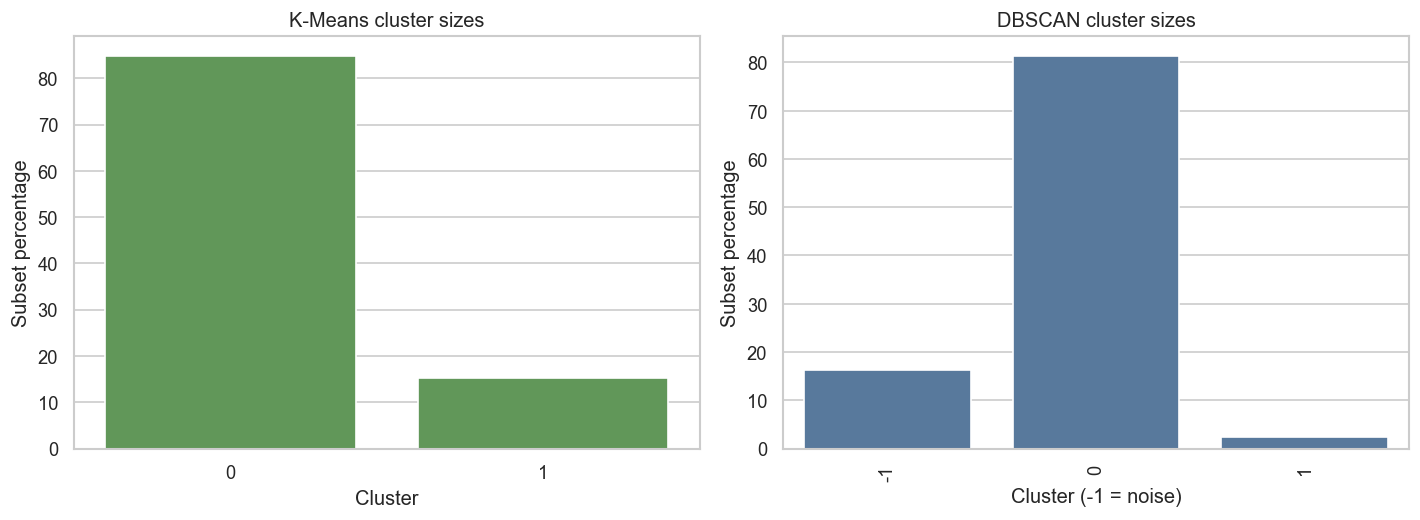

In [12]:
kmeans_cluster_summary = (
    pd.Series(kmeans_labels, name="cluster")
    .value_counts()
    .sort_index()
    .rename_axis("cluster")
    .reset_index(name="count")
)
kmeans_cluster_summary["percentage"] = (kmeans_cluster_summary["count"] / len(kmeans_labels) * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.barplot(data=kmeans_cluster_summary.assign(cluster=lambda d: d["cluster"].astype(str)), x="cluster", y="percentage", color="#59A14F", ax=axes[0])
axes[0].set_title("K-Means cluster sizes")
axes[0].set_xlabel("Cluster")
axes[0].set_ylabel("Subset percentage")

sns.barplot(data=plot_df, x="cluster", y="percentage", color="#4C78A8", ax=axes[1])
axes[1].set_title("DBSCAN cluster sizes")
axes[1].set_xlabel("Cluster (-1 = noise)")
axes[1].set_ylabel("Subset percentage")
axes[1].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


**Comparison interpretation:** K-Means assigns every point to one of the selected clusters, while DBSCAN can mark atypical points as noise. Therefore, DBSCAN's silhouette score must be interpreted together with its noise percentage.


## 12. Answers to Professor Questions Assigned to Alon

### Q3.1 - Example Where Euclidean Distance Is Not Natural

Euclidean distance is not natural for comparing mixed urban objects when numeric closeness does not mean functional similarity. For example, two buildings may have similar lot area and floor area but completely different land-use roles, or two neighborhoods may be geographically close but socio-economically different. Euclidean distance also becomes problematic when features are correlated or high-dimensional.

### Q6.1 - Main Idea Behind DBSCAN

DBSCAN finds clusters as dense regions separated by sparse regions. Points inside dense neighborhoods become core points, nearby points join those clusters, and isolated points are labeled as noise.

### Q6.2 - Dataset Where DBSCAN Performs Well

DBSCAN performs well for irregularly shaped clusters with natural outliers, such as GPS points along roads or pedestrian paths. The clusters do not need to be spherical, and the number of clusters does not need to be known in advance.

### Q6.3 - Dataset Where DBSCAN May Fail

DBSCAN may fail when clusters have very different densities. One global `eps` can be too small for sparse clusters and too large for dense clusters. This is relevant for PLUTO because dense areas and low-density areas may need different neighborhood radii.

### Q6.6 - Noise Point in the Toy Example

With `eps=0.5` and `min_samples=3`, the point `[8.0, 1.0]` is labeled as noise because it is not within the required dense neighborhood of either compact group.

### Q6.7 - How Labels Change When `eps` Changes

In the tested toy example values `eps=0.3`, `0.5`, `1.0`, and `3.0`, the labels do not change. The two compact groups remain separate clusters and `[8.0, 1.0]` remains noise. We should not claim merging or absorption unless a larger tested `eps` actually shows that behavior.

### Q9.1 - Why the Curse of Dimensionality Affects K-Means and DBSCAN

In high-dimensional data, distances become less informative because points tend to appear similarly far apart. K-Means is affected because centroids become less representative and cluster boundaries become less meaningful. DBSCAN is affected because choosing `eps` becomes difficult: a radius may include almost no points or too many points. Standardizing and limiting the feature set helps, but distance-based clustering still becomes harder as dimensionality grows.


## 13. Short Conclusion

Alon's notebook uses Elie's validated preprocessing output, applies DBSCAN to a reproducible 10,000-row subset, tunes `eps` and `min_samples`, reports cluster/noise/silhouette behavior, and compares DBSCAN with K-Means on the exact same rows. DBSCAN adds a density-based view of the data and identifies noise points, while K-Means provides full coverage of the subset.
